## Data cleaning & Preprocessing
Data cleaning involves identifying and removing any missing, duplicate or irrelevant data.

- Raw data (log file, transactions, audio /video recordings, etc) is often noisy, incomplete and inconsistent which can negatively impact the accuracy of the model.
- The goal of data cleaning is to ensure that the data is accurate, consistent and free of errors.
- Clean datasets are also important in EDA (Exploratory Data Analysis), which enhances the interpretability of data so that the right actions can be taken based on insights.

### How to Perform Data Cleaning
Data cleaning involves identifying issues like missing values, duplicates, and outliers, followed by applying appropriate techniques to fix them. The following steps are essential to perform data cleaning:

- Remove Unwanted Observations: Eliminate duplicates, irrelevant entries or redundant data that add noise.
- Fix Structural Errors: Standardize data formats and variable types for consistency.
- Manage Outliers: Detect and handle extreme values that can skew results, either by removal or transformation.
- Handle Missing Data: Address gaps using imputation, deletion or advanced techniques to maintain accuracy and integrity.

### Implementation for Data Cleaning

#### Import Libraries and Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Titanic-Dataset (1).csv')

In [2]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#### EDA (Exploratory Data Analysis)

**Exploratory Data Analysis (EDA)** is an important step in data analysis where we explore and visualise the data to understand its main features, find patterns and see how different variables are related.

Importance
- Provides a clear understanding of the dataset, including the number of features, data types and data distribution.
- Reveals patterns and relationships between different variables in the data.
- Identifies errors and outliers that may affect analysis.
- Highlights the most important features useful for building models.
- Supports selecting suitable modelling techniques for better results.

#### Types of Exploratory Data Analysis

1. Univariate Analysis
2. Bivariate Analysis
3. Multivariate Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Check for Distribution of numeric values

In [5]:
# Drop PassengerId
# PassengerId is just an identifier, not a feature.
df1 = df.drop(columns=['PassengerId'])

In [6]:
# Select numeric columns
numeric_cols = df1.select_dtypes(include=['int64', 'float64']).columns
print(numeric_cols)

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='str')


In [ ]:
# Plot distributions (before scaling)
# Histograms for all numeric columns
for col in numeric_cols:
    plt.figure()
    sns.histplot(df1[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

### Target Variable Analysis (Survival)

In [8]:
df1['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [ ]:
sns.countplot(x='Survived', data=df1)
plt.show()

#### Survival vs Gender

In [ ]:
sns.barplot(x='Sex', y='Survived', data=df1)
plt.show()

#### Survival vs Passenger Class

In [ ]:
sns.barplot(x='Pclass', y='Survived', data=df1)
plt.show()

#### Age Distribution

In [ ]:
df1['Age'].hist(bins=30)
plt.title("Age Distribution")
plt.show()

#### Age vs Survival

In [ ]:
sns.boxplot(x='Survived', y='Age', data=df1)
plt.show()

Younger passengers had slightly higher survival chance

#### Fare Distribution

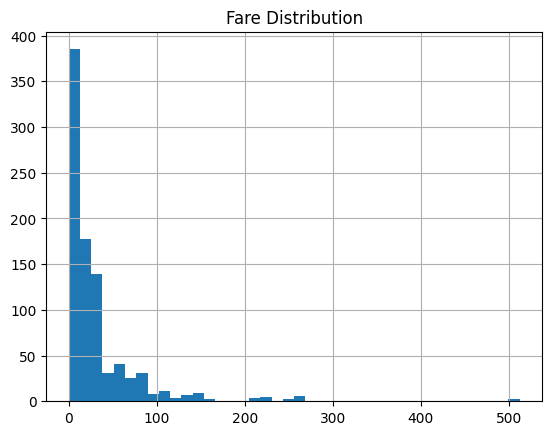

In [13]:
df1['Fare'].hist(bins=40)
plt.title("Fare Distribution")
plt.show()

Highly skewed (few people paid very high fares)

#### Correlation Analysis

In [ ]:
sns.heatmap(df1.corr(numeric_only=True), annot=True)
plt.show()

#### Missing Values Analysis

In [ ]:
df1.isnull().sum()

In [ ]:
# convert to percentage
missing_percent = df1.isnull().sum() / len(df1) * 100
print(missing_percent)

#### Visualize missing data

In [44]:
import missingno as msno

In [ ]:
msno.matrix(df1)
plt.show()

#### Interpret the missingness (VERY important in EDA)
- Age (moderate missing)
Likely missing at random
Can be imputed (mean/median)
- Cabin (very high missing)
Too much missing → often dropped
Or engineered into feature (e.g. "has cabin")
- Embarked (very low missing)
Easy fix → mode imputation

#### Drop Irrelevant or Data-Heavy Missing Columns

- `df.drop(columns=[])`: Drops specified columns from the DataFrame.
- `fillna()`: Fills missing values with specified value (e.g., mean).

In [15]:
# preprocessing decisions

# drop irrelevant columns (Name, Ticket)
df2 = df1.drop(columns=['Name', 'Ticket', 'Cabin'])

# Age → mean imputation
df2['Age'] = df2['Age'].fillna(df2['Age'].mean())

# Embarked → mode imputation
df2['Embarked'] = df2['Embarked'].fillna(df2['Embarked'].mode()[0])

#### Detect Outliers with Box Plot

- `matplotlib.pyplot.boxplot()`: Displays distribution of data, highlighting median, quartiles and outliers.
- `plt.show()`: Renders the plot.

In [ ]:
import matplotlib.pyplot as plt

plt.boxplot(df2['Age'], vert=False)
plt.ylabel('Variable')
plt.xlabel('Age')
plt.title('Box Plot')
plt.show()

#### Calculate Outlier Boundaries and Remove Them

In [17]:
# Compute Q1, Q3, IQR
Q1 = df2['Age'].quantile(0.25)
Q3 = df2['Age'].quantile(0.75)
IQR = Q3 - Q1

In [18]:
# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [19]:
# Filter the data
df_no_outliers = df2[(df2['Age'] >= lower_bound) & (df2['Age'] <= upper_bound)]

In [20]:
# Check how many you removed
print("Before:", len(df2))
print("After:", len(df_no_outliers))

Before: 891
After: 825


In [ ]:
plt.boxplot(df_no_outliers['Age'], vert=False)
plt.title('Box Plot Without Outliers')
plt.show()

In [ ]:
df3 = df_no_outliers.fillna(df_no_outliers['Age'].mean())
df3.isnull().sum()

### Encoding 

#### Identify Column Data Types

In [23]:
cat_col = [col for col in df3.columns if df3[col].dtype == 'str']
num_col = [col for col in df3.columns if df3[col].dtype != 'str']

print('Categorical columns:', cat_col)
print('Numerical columns:', num_col)

Categorical columns: ['Sex', 'Embarked']
Numerical columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


#### Count Unique Values in the Categorical Columns

In [24]:
df3[cat_col].nunique()

Sex         2
Embarked    3
dtype: int64

##### Encoding categorical columns: One-Hot Encoding

In [25]:
df4 = pd.get_dummies(df3, columns=['Sex', 'Embarked'], drop_first=True)

In [ ]:
df4.head()

In [27]:
df4.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male         bool
Embarked_Q       bool
Embarked_S       bool
dtype: object

In [28]:
bool_cols = ['Sex_male', 'Embarked_Q', 'Embarked_S']

df4[bool_cols] = df4[bool_cols].astype(int)

In [29]:
df4.dtypes

Survived        int64
Pclass          int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Sex_male        int64
Embarked_Q      int64
Embarked_S      int64
dtype: object

### What is Feature Scaling?

Feature scaling puts numerical variables on a similar scale so that no feature dominates others just because of its magnitude.

Example:

- Age: 0–80
- Fare: 0–500+
- SibSp: 0–8

> Without scaling, Fare would dominate models like Logistic Regression or KNN

#### Decide what to scale

##### Do NOT scale:
- Survived (target)
- Sex_male, Embarked_Q, Embarked_S (already 0/1 encoded features)
- Pclass (optional — often left as-is since it’s ordinal)

##### Scale:
- Age - roughly normal with slight skew - StandardScaler
- Fare - Strong right skew with a few extremely large values (outliers)
- SibSp - Discrete count feature, Not normally distributed, StandardScaler (or leave unscaled for tree models)
- Parch - Similar to SibSp, discrete count variable

In [30]:
from sklearn.preprocessing import StandardScaler, RobustScaler

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df4[['Age', 'SibSp', 'Parch']] = std_scaler.fit_transform(df4[['Age', 'SibSp', 'Parch']])

df4[['Fare']] = rob_scaler.fit_transform(df4[['Fare']].values.reshape(-1, 1))

##### StandardScaler on Age, SibSp, Parch
- Centers data around 0
- Scales by standard deviation
- Good for roughly normal / small-range features

##### RobustScaler on Fare
- Uses median instead of mean
- Uses IQR instead of std
- Handles outliers (very important for Fare)

> `.values.reshape(-1, 1)` is used because:

- RobustScaler expects 2D input

In [31]:
df4[['Age', 'SibSp', 'Parch', 'Fare']].describe()

,Age,SibSp,Parch,Fare
count,8.250000e+02,8.250000e+02,8.250000e+02,825.000000
mean,4.736952e-17,-2.583792e-17,-1.722528e-17,0.814743
std,1.000607e+00,1.000607e+00,1.000607e+00,2.252827
min,-2.543074e+00,-4.659400e-01,-4.480252e-01,-0.605037
25%,-6.760344e-01,-4.659400e-01,-4.480252e-01,-0.248970
50%,8.052132e-02,-4.659400e-01,-4.480252e-01,0.000000
75%,5.031486e-01,4.514836e-01,-4.480252e-01,0.751030
max,2.468454e+00,6.873449e+00,7.069685e+00,22.498873


This causes data leakage:

- The scaler learns from all data (including test data)
- That means your model indirectly “sees” the test set during training
- Results become overly optimistic and unrealistic

#### Correct place to apply scaling

#### After train-test split

#### Define features and target

In [32]:
X = df4.drop(columns=['Survived'])
y = df4['Survived']

#### Train-test split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#### Apply scaling

In [34]:
from sklearn.preprocessing import StandardScaler, RobustScaler

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

cols_std = ['Age', 'SibSp', 'Parch']
cols_rob = ['Fare']

# Fit on training data
X_train[cols_std] = std_scaler.fit_transform(X_train[cols_std])
X_train[cols_rob] = rob_scaler.fit_transform(X_train[cols_rob])

# Transform test data
X_test[cols_std] = std_scaler.transform(X_test[cols_std])
X_test[cols_rob] = rob_scaler.transform(X_test[cols_rob])

#### Train Logistic Regression Model

In [35]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### Make Predictions

In [36]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

###### How it works internally:
1. Model computes probability using logistic function
2. Applies a threshold (default = 0.5)
3. Converts to class:
- If probability ≥ 0.5 → 1
- If probability < 0.5 → 0

#### Basic Evaluation

In [37]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8242424242424242

#### Full Evaluation Metrics

In [38]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred)

array([[85, 14],
       [15, 51]])

- True Negatives (TN = 85)
Correctly predicted passengers who did not survive
- False Positives (FP = 14)
Predicted survived, but actually did not survive
- False Negatives (FN = 15)
Predicted did not survive, but actually survived
- True Positives (TP = 51)
Correctly predicted passengers who survived

#### Precision / Recall / F1

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.86      0.85        99
           1       0.78      0.77      0.78        66

    accuracy                           0.82       165
   macro avg       0.82      0.82      0.82       165
weighted avg       0.82      0.82      0.82       165



- Precision → Of all predicted instances of a class, how many were correct
- Recall → Of all actual instances of a class, how many were correctly identified
- F1-score → Balance between precision and recall
- Support → Number of actual samples in that class

##### Class-wise Interpretation
Class 0 (Did NOT Survive)

- Precision: 0.85 → 85% of predicted non-survivors were correct
- Recall: 0.86 → 86% of actual non-survivors were correctly identified
- F1-score: 0.85 → Strong balance between precision and recall
- Support: 99 → There are 99 non-survivors

> The model performs very well on this class

Class 1 (Survived)

- Precision: 0.78 → 78% of predicted survivors were correct
- Recall: 0.77 → 77% of actual survivors were correctly identified
- F1-score: 0.78 → Slightly lower than class 0
- Support: 66 → There are 66 survivors

> The model performs moderately well, but worse than class 0

#### ROC-AUC

In [40]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob)

0.8827670645852463

### Error Analysis
#### Build results table

In [41]:
import pandas as pd

results = X_test.copy()
results['Actual'] = y_test.values
results['Predicted'] = y_pred
results['Probability'] = y_prob

#### Extract mistakes

In [42]:
errors = results[results['Actual'] != results['Predicted']]
errors.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S,Actual,Predicted,Probability
444,3,0.097456,-0.448849,-0.448850,-0.230225,1,0,1,1,0,0.093846
724,1,-0.166812,0.438098,-0.448850,1.888908,1,0,1,1,0,0.444059
233,3,-2.320809,3.098936,2.072351,0.866142,0,0,1,1,0,0.498704
852,3,-1.929174,0.438098,0.811750,0.105788,0,0,0,0,1,0.729985
766,1,0.097456,-0.448849,-0.448850,1.252991,1,0,0,0,1,0.558006


### Pattern analysis
#### Where are errors happening?

In [43]:
errors['Pclass'].value_counts()

Pclass
3    19
1     8
2     2
Name: count, dtype: int64

#### Gender-related errors

In [45]:
errors['Sex_male'].value_counts()

Sex_male
1    16
0    13
Name: count, dtype: int64

#### Confidence analysis

- High probability but wrong → model overconfident
- Low probability mistakes → uncertainty area

In [46]:
errors[['Actual', 'Predicted', 'Probability']].head()

,Actual,Predicted,Probability
444,1,0,0.093846
724,1,0,0.444059
233,1,0,0.498704
852,0,1,0.729985
766,0,1,0.558006


#### Threshold tuning

Default threshold = 0.5

In [47]:
y_pred_new = (y_prob > 0.4).astype(int)

In [48]:
confusion_matrix(y_test, y_pred_new)

array([[76, 23],
       [11, 55]])

#### Train SVM Model

In [49]:
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


#### Make Predictions

In [50]:
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]

#### Evaluate SVM Model

In [51]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred_svm)

0.8

#### Confusion Matrix

In [52]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_svm)

array([[86, 13],
       [20, 46]])

#### Classification Report

In [53]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_svm))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84        99
           1       0.78      0.70      0.74        66

    accuracy                           0.80       165
   macro avg       0.80      0.78      0.79       165
weighted avg       0.80      0.80      0.80       165



##### ROC-AUC Score

In [54]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, y_prob_svm)

0.8699112335475973

##### Compare Logistic Regression vs SVM

In [55]:
print("Logistic Accuracy:", accuracy_score(y_test, y_pred))
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("Logistic ROC-AUC:", roc_auc_score(y_test, y_prob))
print("SVM ROC-AUC:", roc_auc_score(y_test, y_prob_svm))

Logistic Accuracy: 0.8242424242424242
SVM Accuracy: 0.8
Logistic ROC-AUC: 0.8827670645852463
SVM ROC-AUC: 0.8699112335475973


##### Logistic Regression vs SVM

| Model               | How it works                   | Best for                            |
| ------------------- | ------------------------------ | ----------------------------------- |
| Logistic Regression | Probability-based linear model | Simple, interpretable problems      |
| SVM                 | Finds best separating margin   | Complex boundaries, higher accuracy |


#### Bagging Model (Random Forest)

In [57]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

#### Predictions

In [58]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

#### Evaluation

In [59]:
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Random Forest ROC-AUC:", roc_auc_score(y_test, y_prob_rf))

print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8242424242424242
Random Forest ROC-AUC: 0.8810070400979492
              precision    recall  f1-score   support

           0       0.80      0.94      0.87        99
           1       0.88      0.65      0.75        66

    accuracy                           0.82       165
   macro avg       0.84      0.80      0.81       165
weighted avg       0.83      0.82      0.82       165



#### Feature Importance

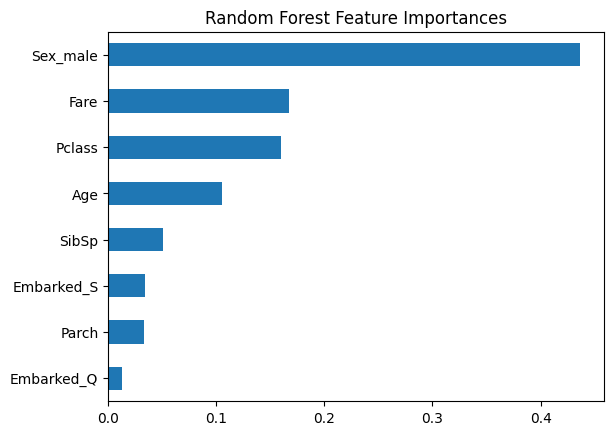

In [60]:
feat_importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values()

feat_importances.plot(kind="barh")
plt.title("Random Forest Feature Importances")
plt.show()

#### Boosting Models

##### AdaBoost

In [61]:
from sklearn.ensemble import AdaBoostClassifier

ada_model = AdaBoostClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada_model.fit(X_train, y_train)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",0.1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [62]:
y_pred_ada = ada_model.predict(X_test)
y_prob_ada = ada_model.predict_proba(X_test)[:, 1]

In [63]:
print("AdaBoost Accuracy:", accuracy_score(y_test, y_pred_ada))
print("AdaBoost ROC-AUC:", roc_auc_score(y_test, y_prob_ada))

AdaBoost Accuracy: 0.806060606060606
AdaBoost ROC-AUC: 0.8653198653198653


#### Gradient boosting

In [64]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [65]:
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [66]:
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Gradient Boosting Accuracy: 0.8181818181818182
Gradient Boosting ROC-AUC: 0.8935567799204163


#### Train XGBoost Model

In [67]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)

c:\Users\user\Desktop\data-science-class\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:46:05] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [68]:
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [69]:
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("XGBoost ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.8181818181818182
XGBoost ROC-AUC: 0.8936333027242118
              precision    recall  f1-score   support

           0       0.82      0.90      0.86        99
           1       0.82      0.70      0.75        66

    accuracy                           0.82       165
   macro avg       0.82      0.80      0.80       165
weighted avg       0.82      0.82      0.82       165



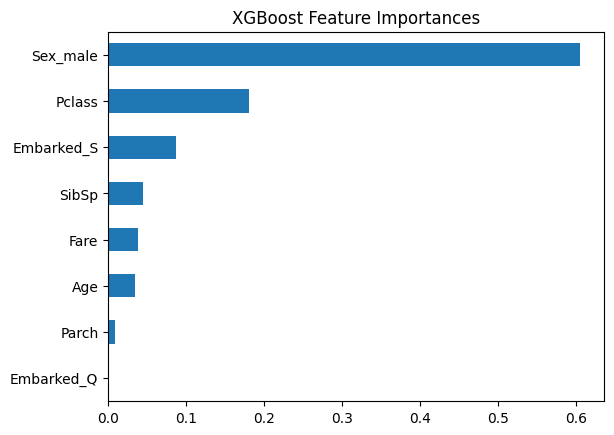

In [70]:
feat_importances_xgb = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values()

feat_importances_xgb.plot(kind="barh")
plt.title("XGBoost Feature Importances")
plt.show()